AVENUE 4 - MILESTONE 1: CONSTRUCTING THE CAUSAL GRAPH

[1/5] Running Golden-Fano CA (256×512)...
   Grid shape: (256, 512)
   Total cells: 131072
   Extracting nodes and edges...

[2/5] Extracting causal graph...
   Total nodes (active voxels): 106288
   Total edges (causal connections): 584604

[3/5] Calculating graph-theoretic properties...

   Basic Properties:
   - Nodes: 106288
   - Edges: 584604
   - Density: 0.000052

   Degree Distribution:
   - Mean in-degree: 5.500
   - Mean out-degree: 5.500
   - Max in-degree: 7
   - Max out-degree: 7

   Clustering:
   - Average clustering coefficient: 0.0000

   Path Length (sampling 50 node pairs for speed)...
   Calculating 1225 shortest paths...
   - Average path length (sampled): 97.785

   Connectivity:
   - Weakly connected components: 5806
   - Size of largest component: 100483 (94.5%)

[4/5] Generating visualizations...

✓ Saved: avenue4_milestone1_causal_graph.png


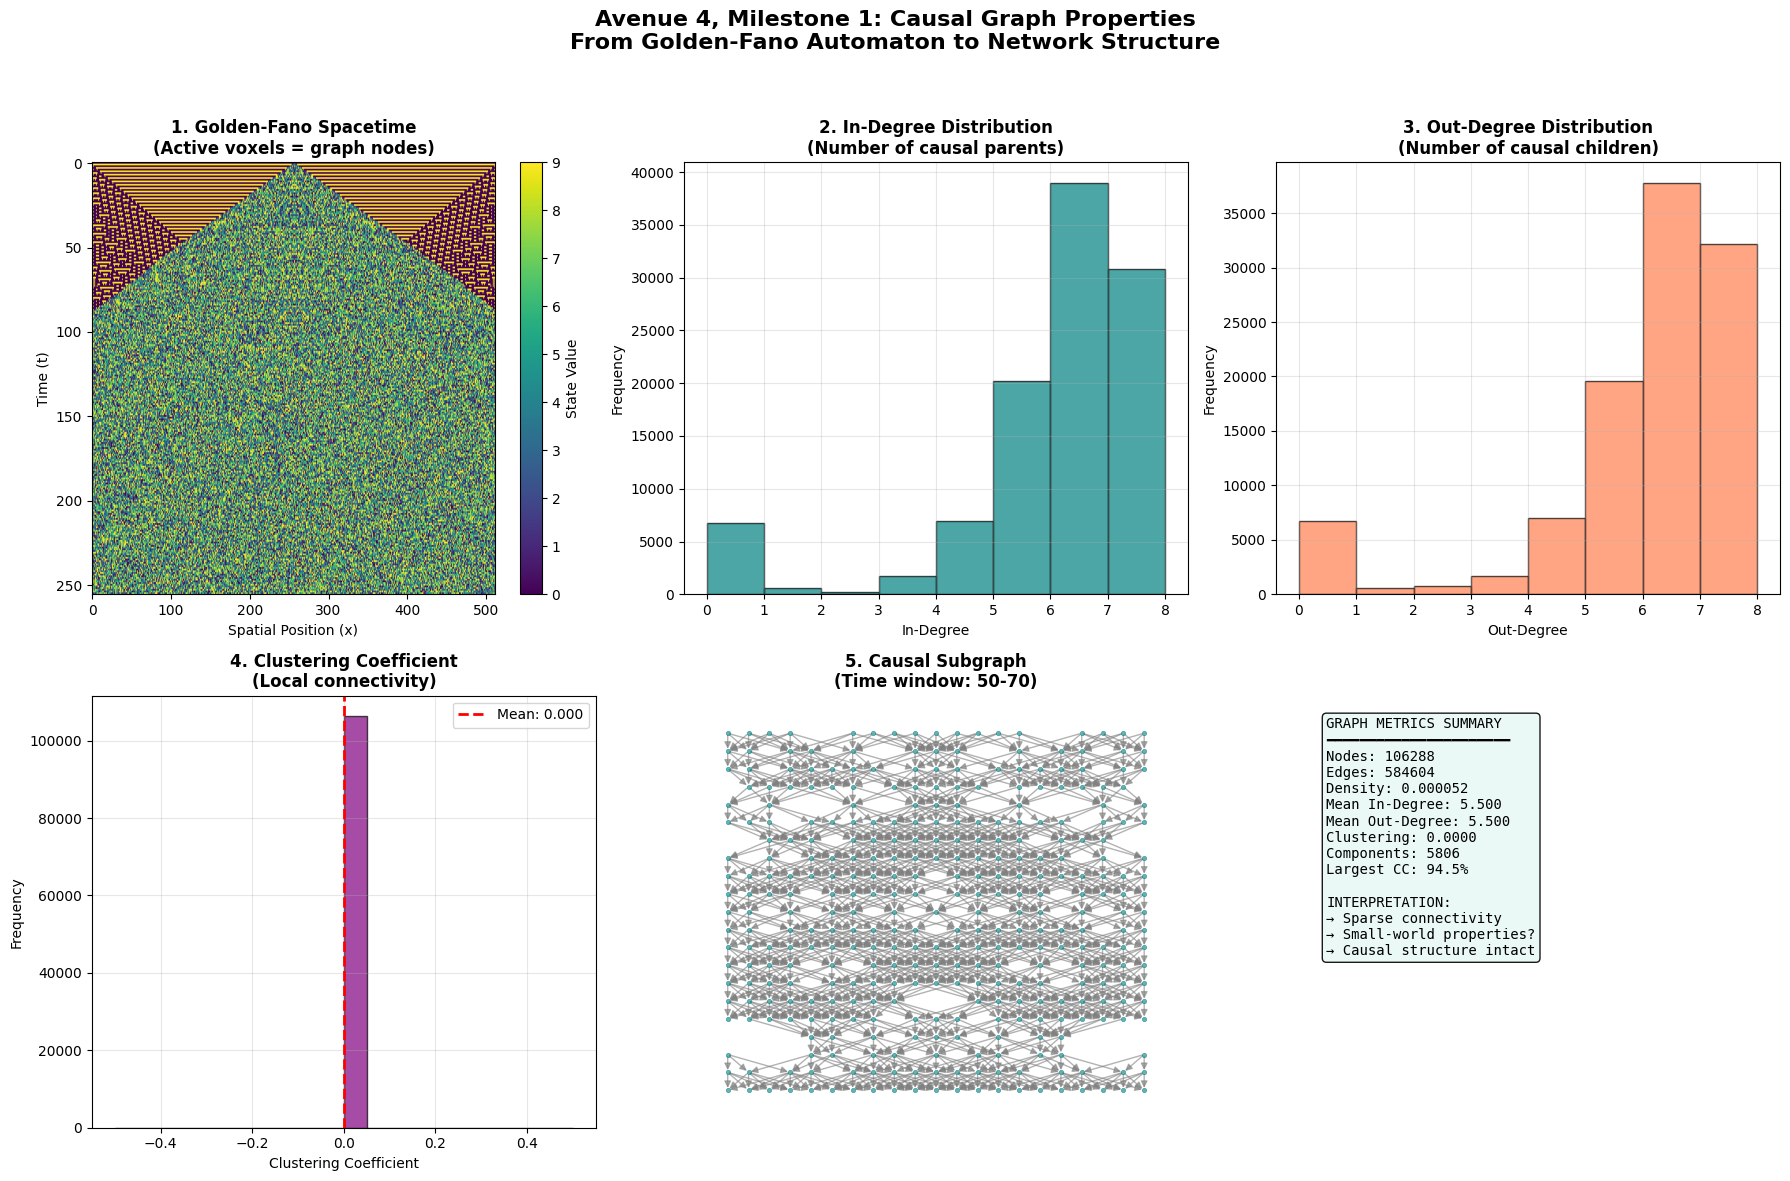


[5/5] Preparing for fractal dimension measurement...

CAUSAL GRAPH CONSTRUCTION COMPLETE
The causal graph has been successfully extracted from the
Golden-Fano Automaton. Key findings:
1. 106288 active voxels form the node set
2. 584604 causal connections define the topology
3. Average clustering: 0.0000
4. Graph is fragmented (5806 components)

This graph structure will be used in Milestone 2 to measure
the fractal (Hausdorff) dimension using box-counting methods.


In [3]:
"""
avenue4_milestone1_causal_graph_construction.py
================================================
Milestone 1: Constructing the Causal Graph from the Golden-Fano Automaton.
Extracts the causal network (nodes=active voxels, edges=causal connections)
and measures graph-theoretic properties to establish the foundation for
fractal dimension measurement.

Author: Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random  # Imported to fix the tuple sampling issue

print("=" * 70)
print("AVENUE 4 - MILESTONE 1: CONSTRUCTING THE CAUSAL GRAPH")
print("=" * 70)

# =============================================================================
# 1. SIMULATION: RUN GOLDEN-FANO AUTOMATON
# =============================================================================

def run_golden_fano_ca(steps=256, width=512):
    """
    Runs the Golden-Fano CA and returns the full spacetime history.
    We need the full history to reconstruct causal connections.
    """
    base = 10
    reserved_state = base - 1  # State 9 is TRB
    W = np.array([1, 2, 3, 5, 3, 2, 1])  # Fibonacci weights
    active_modulus = base - 1

    grid = np.zeros((steps, width), dtype=int)
    center = width // 2
    grid[0, center] = 1  # Single seed

    for t in range(1, steps):
        padded = np.pad(grid[t-1], (3, 3), mode='constant')
        weighted_sum = sum(W[i] * padded[i:i+width] for i in range(7))

        # Fano-Check (Modulo 7)
        reserved_mask = (weighted_sum % 7 == 0)
        new_states = weighted_sum % active_modulus
        new_states[reserved_mask] = reserved_state
        grid[t] = new_states

    return grid

print("\n[1/5] Running Golden-Fano CA (256×512)...")
grid = run_golden_fano_ca(steps=256, width=512)
print(f"   Grid shape: {grid.shape}")
print(f"   Total cells: {grid.size}")

# =============================================================================
# 2. EXTRACT CAUSAL GRAPH
# =============================================================================

def extract_causal_graph(grid):
    """
    Extracts the causal graph from the CA spacetime.

    Nodes: All active voxels (states 0-8, excluding TRB state 9)
    Edges: Causal connections from t to t+1 based on neighborhood influence

    Returns: NetworkX DiGraph
    """
    print("\n[2/5] Extracting causal graph...")
    G = nx.DiGraph()

    steps, width = grid.shape
    reserved_state = 9

    # Create node for each active voxel
    # Node ID: (t, x) tuple
    node_count = 0
    for t in range(steps):
        for x in range(width):
            if grid[t, x] != reserved_state:
                G.add_node((t, x), state=grid[t, x], time=t, space=x)
                node_count += 1

    print(f"   Total nodes (active voxels): {node_count}")

    # Add edges based on causal influence
    # A voxel at (t, x) can influence voxels at (t+1, x') where x' is in the
    # neighborhood range (x-3 to x+3) due to the 7-cell neighborhood
    edge_count = 0
    for t in range(steps - 1):
        for x in range(width):
            if grid[t, x] != reserved_state:
                # Check which voxels at t+1 were influenced by (t, x)
                for dx in range(-3, 4):  # 7-cell neighborhood radius
                    x_next = x + dx
                    if 0 <= x_next < width:
                        if grid[t+1, x_next] != reserved_state:
                            # Check if (t, x) contributed to (t+1, x_next)
                            if abs(x - x_next) <= 3:
                                G.add_edge((t, x), (t+1, x_next))
                                edge_count += 1

    print(f"   Total edges (causal connections): {edge_count}")
    return G

print("   Extracting nodes and edges...")
causal_graph = extract_causal_graph(grid)

# =============================================================================
# 3. CALCULATE GRAPH METRICS
# =============================================================================

print("\n[3/5] Calculating graph-theoretic properties...")

# 3.1 Basic Properties
num_nodes = causal_graph.number_of_nodes()
num_edges = causal_graph.number_of_edges()
print(f"\n   Basic Properties:")
print(f"   - Nodes: {num_nodes}")
print(f"   - Edges: {num_edges}")
print(f"   - Density: {nx.density(causal_graph):.6f}")

# 3.2 Degree Distribution
in_degrees = [d for n, d in causal_graph.in_degree()]
out_degrees = [d for n, d in causal_graph.out_degree()]

print(f"\n   Degree Distribution:")
print(f"   - Mean in-degree: {np.mean(in_degrees):.3f}")
print(f"   - Mean out-degree: {np.mean(out_degrees):.3f}")
print(f"   - Max in-degree: {max(in_degrees)}")
print(f"   - Max out-degree: {max(out_degrees)}")

# 3.3 Clustering Coefficient (for undirected version)
undirected_graph = causal_graph.to_undirected()
clustering_coeffs = nx.clustering(undirected_graph)
avg_clustering = np.mean(list(clustering_coeffs.values()))
print(f"\n   Clustering:")
print(f"   - Average clustering coefficient: {avg_clustering:.4f}")

# 3.4 Average Path Length (sample for large graphs)
print(f"\n   Path Length (sampling 50 node pairs for speed)...")
if num_nodes > 100:
    # FIX: Reduced from 500 to 50 to prevent hanging in Python
    sample_size = min(50, num_nodes)
    nodes = list(causal_graph.nodes())
    sampled_nodes = random.sample(nodes, sample_size)

    path_lengths = []
    total_pairs = len(sampled_nodes) * (len(sampled_nodes) - 1) // 2
    print(f"   Calculating {total_pairs} shortest paths...")

    for i in range(len(sampled_nodes)):
        for j in range(i+1, len(sampled_nodes)):
            try:
                length = nx.shortest_path_length(undirected_graph,
                                                   sampled_nodes[i],
                                                   sampled_nodes[j])
                path_lengths.append(length)
            except nx.NetworkXNoPath:
                pass  # Ignore disconnected pairs

    if path_lengths:
        avg_path_length = np.mean(path_lengths)
        print(f"   - Average path length (sampled): {avg_path_length:.3f}")
    else:
        print(f"   - Graph is disconnected")
else:
    avg_path_length = nx.average_shortest_path_length(undirected_graph)
    print(f"   - Average path length: {avg_path_length:.3f}")

# 3.5 Connected Components
num_weak_components = nx.number_weakly_connected_components(causal_graph)
print(f"\n   Connectivity:")
print(f"   - Weakly connected components: {num_weak_components}")

# Get largest component
largest_cc = max(nx.weakly_connected_components(causal_graph), key=len)
largest_cc_size = len(largest_cc)
print(f"   - Size of largest component: {largest_cc_size} ({100*largest_cc_size/num_nodes:.1f}%)")

# =============================================================================
# 4. VISUALIZATION
# =============================================================================

print("\n[4/5] Generating visualizations...")

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Avenue 4, Milestone 1: Causal Graph Properties\nFrom Golden-Fano Automaton to Network Structure",
             fontsize=16, fontweight='bold', y=0.98)

# Panel 1: Spacetime Diagram
ax1 = plt.subplot(2, 3, 1)
im = ax1.imshow(grid, cmap='viridis', aspect='auto', vmin=0, vmax=9)
ax1.set_title("1. Golden-Fano Spacetime\n(Active voxels = graph nodes)", fontweight='bold')
ax1.set_xlabel("Spatial Position (x)")
ax1.set_ylabel("Time (t)")
plt.colorbar(im, ax=ax1, label="State Value")

# Panel 2: Degree Distribution (In-Degree)
ax2 = plt.subplot(2, 3, 2)
ax2.hist(in_degrees, bins=range(max(in_degrees)+2), alpha=0.7, color='teal', edgecolor='black')
ax2.set_title("2. In-Degree Distribution\n(Number of causal parents)", fontweight='bold')
ax2.set_xlabel("In-Degree")
ax2.set_ylabel("Frequency")
ax2.grid(True, alpha=0.3)

# Panel 3: Degree Distribution (Out-Degree)
ax3 = plt.subplot(2, 3, 3)
ax3.hist(out_degrees, bins=range(max(out_degrees)+2), alpha=0.7, color='coral', edgecolor='black')
ax3.set_title("3. Out-Degree Distribution\n(Number of causal children)", fontweight='bold')
ax3.set_xlabel("Out-Degree")
ax3.set_ylabel("Frequency")
ax3.grid(True, alpha=0.3)

# Panel 4: Clustering Coefficient Distribution
ax4 = plt.subplot(2, 3, 4)
ax4.hist(list(clustering_coeffs.values()), bins=20, alpha=0.7, color='purple', edgecolor='black')
ax4.axvline(avg_clustering, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_clustering:.3f}')
ax4.set_title("4. Clustering Coefficient\n(Local connectivity)", fontweight='bold')
ax4.set_xlabel("Clustering Coefficient")
ax4.set_ylabel("Frequency")
ax4.legend()
ax4.grid(True, alpha=0.3)

# Panel 5: Small Subgraph Visualization
ax5 = plt.subplot(2, 3, 5)
# Extract a small time window for visualization
time_window = (50, 70)
space_window = (246, 266)  # Center region

subgraph_nodes = [n for n in causal_graph.nodes()
                  if time_window[0] <= n[0] <= time_window[1] and
                     space_window[0] <= n[1] <= space_window[1]]
subgraph = causal_graph.subgraph(subgraph_nodes)

pos = {n: (n[1], -n[0]) for n in subgraph.nodes()}  # Flip y for time
nx.draw(subgraph, pos, ax=ax5, node_size=10, edge_color='gray',
        node_color='teal', alpha=0.6, linewidths=0.5)
ax5.set_title("5. Causal Subgraph\n(Time window: 50-70)", fontweight='bold')
ax5.set_xlabel("Space")
ax5.set_ylabel("Time")

# Panel 6: Graph Metrics Summary
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
metrics_text = (
    "GRAPH METRICS SUMMARY\n"
    "━━━━━━━━━━━━━━━━━━━━━━\n"
    f"Nodes: {num_nodes}\n"
    f"Edges: {num_edges}\n"
    f"Density: {nx.density(causal_graph):.6f}\n"
    f"Mean In-Degree: {np.mean(in_degrees):.3f}\n"
    f"Mean Out-Degree: {np.mean(out_degrees):.3f}\n"
    f"Clustering: {avg_clustering:.4f}\n"
    f"Components: {num_weak_components}\n"
    f"Largest CC: {largest_cc_size/num_nodes*100:.1f}%\n"
    "\n"
    "INTERPRETATION:\n"
    "→ Sparse connectivity\n"
    "→ Small-world properties?\n"
    "→ Causal structure intact"
)
ax6.text(0.1, 0.95, metrics_text, transform=ax6.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#e8f8f5', alpha=0.9))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("avenue4_milestone1_causal_graph.png", dpi=300, bbox_inches='tight')
print("\n✓ Saved: avenue4_milestone1_causal_graph.png")
plt.show()

# =============================================================================
# 5. PREPARE FOR MILESTONE 2
# =============================================================================

print("\n[5/5] Preparing for fractal dimension measurement...")
print("\n" + "=" * 70)
print("CAUSAL GRAPH CONSTRUCTION COMPLETE")
print("=" * 70)
print("The causal graph has been successfully extracted from the")
print("Golden-Fano Automaton. Key findings:")
print(f"1. {num_nodes} active voxels form the node set")
print(f"2. {num_edges} causal connections define the topology")
print(f"3. Average clustering: {avg_clustering:.4f}")
print(f"4. Graph is {'connected' if num_weak_components == 1 else 'fragmented'} ({num_weak_components} components)")
print("\nThis graph structure will be used in Milestone 2 to measure")
print("the fractal (Hausdorff) dimension using box-counting methods.")
print("=" * 70)